In [1]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
db = pd.read_csv(r"C:\Users\nikit\Downloads\Python Folder\Cluster\114_congress.csv")
db.head(10)

,name,party,state,00001,00004,00005,00006,00007,00008,00009,00010,00020,00026,00032,00038,00039,00044,00047
0,Alexander,R,TN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Ayotte,R,NH,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,Baldwin,D,WI,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
3,Barrasso,R,WY,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,Bennet,D,CO,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,Blumenthal,D,CT,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
6,Blunt,R,MO,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
7,Booker,D,NJ,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
8,Boozman,R,AR,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
9,Boxer,D,CA,0.5,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0


In [3]:
db.columns

Index(['name', 'party', 'state', '00001', '00004', '00005', '00006', '00007',
       '00008', '00009', '00010', '00020', '00026', '00032', '00038', '00039',
       '00044', '00047'],
      dtype='object')

In [4]:
db.shape

(100, 18)

In [5]:
df = db['party'].value_counts(0)
df.to_frame()

,count
party,
R,54
D,44
I,2


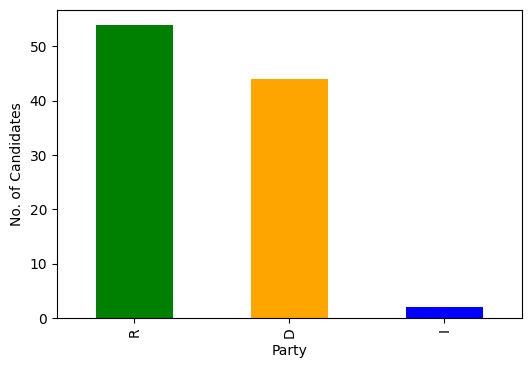

In [6]:
plt.figure(figsize = (6,4))
df.plot(kind = 'bar', color = ['g', 'orange', 'blue'])
plt.xlabel('Party')
plt.ylabel('No. of Candidates')
plt.show()

In [7]:
db.mean(numeric_only=True)

00001    0.325
00004    0.575
00005    0.535
00006    0.945
00007    0.545
00008    0.415
00009    0.545
00010    0.985
00020    0.525
00026    0.545
00032    0.410
00038    0.480
00039    0.510
00044    0.460
00047    0.370
dtype: float64

In [8]:
from sklearn.metrics.pairwise import euclidean_distances
distance=euclidean_distances(db.iloc[0,3:].to_numpy().reshape(1,-1),db.iloc[1,3:].to_numpy().reshape(1,-1))
distance

array([[1.73205081]])

In [9]:
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=2,random_state=1)
senator_distances = kmeans_model.fit_transform(db.iloc[:,3:])
labels=kmeans_model.labels_
labels

array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0], dtype=int32)

In [10]:
db['distance_cluster1'] = senator_distances[:,0]
db['distance_cluster2'] = senator_distances[:,1]
db['labels'] = labels

In [11]:
db.head()

,name,party,state,00001,00004,00005,00006,00007,00008,00009,...,00020,00026,00032,00038,00039,00044,00047,distance_cluster1,distance_cluster2,labels
0,Alexander,R,TN,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.055495,1.327957,1
1,Ayotte,R,NH,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.556570,2.088892,1
2,Baldwin,D,WI,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.397834,3.471942,0
3,Barrasso,R,WY,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,3.347046,0.190259,1
4,Bennet,D,CO,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.399383,3.024118,0


In [12]:
pd.crosstab(labels,db['party'])

party,D,I,R
row_0,,,
0,43,2,0
1,1,0,54


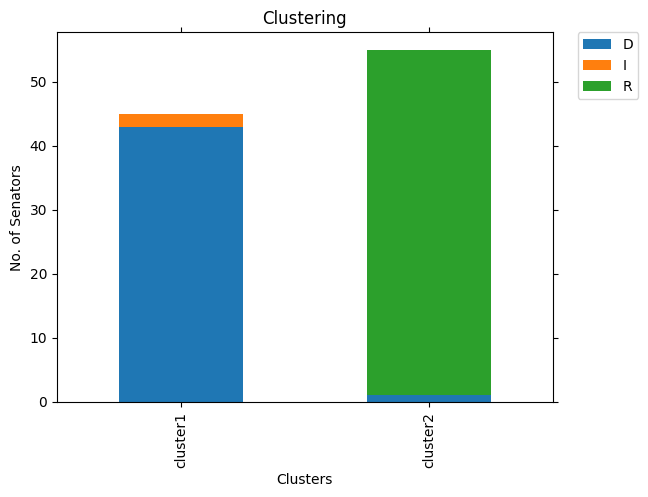

In [13]:
pd.crosstab(labels,db['party']).plot(kind='bar',stacked=True)
x=[0,1]
l=['cluster1','cluster2']
plt.xticks(x,l)
plt.title('Clustering')
plt.xlabel('Clusters')
plt.ylabel('No. of Senators')
plt.tick_params(bottom='off',top='off',right='off',left='off')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [16]:
democratic_outlier = db[(labels == 1) & (db['party'] == 'D')]
democratic_outlier[['name','party']]

,name,party
56,Manchin,D


In [17]:
democratic_outlier = db[(labels == 0) & (db['party'] == 'I')]
democratic_outlier[['name','party']]

,name,party
50,King,I
79,Sanders,I


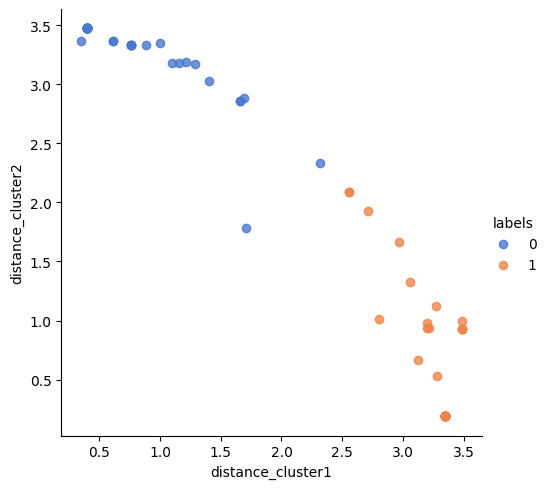

In [20]:
sns.lmplot(x = 'distance_cluster1', y = 'distance_cluster2', hue = 'labels', data = db, fit_reg = False, palette = 'muted')

In [21]:
extremism = (senator_distances ** 3).sum(axis = 1)
db['extremism'] = extremism
db.sort_values('extremism', inplace = True, ascending = False)

In [23]:
db[['name', 'party', 'extremism']].head(5)

,name,party,extremism
98,Wicker,R,43.510363
26,Cruz,R,43.300337
53,Lankford,R,43.300337
69,Paul,R,43.300337
80,Sasse,R,43.300337
